### Marketing Spend Case Study 

This notebook aims to detail the step-by-step of exploring and transforming the marketing spend data into a structured narrative for a stakeholder presentation.

The below datasets are shared for this analysis:

1. **Key SKUs:** A list of the most purchased products
2. **Online Transactions:** Records of online transactions on a day to day level for a period of 12 months
3. **Offline Transactions:**  Records of offline transactions on a day to day level for a period of 12 months
4. **Marketing Spend:** Records of day to day marketing spend split between offline and online

For this analysis, we will import all csv files into BigQuery for data preview and exploration. From here, 4 tables have been created:

1. **Key SKUs:** `mkt-cs-383113.marketing.catalog`
2. **Online Transactions:** `mkt-cs-383113.marketing.sales_online`
3. **Offline Transactions:** `mkt-cs-383113.marketing.sales_retail`
4. **Marketing Spend:** `mkt-cs-383113.marketing.mktg_cost`


**Phase 1 - Data Transformation on BigQuery**

- Unify offline and online sales using Common Table Expressions `WITH BASE` by:
    - Parsing and cleaning dates
    - Standardizing the schema across channels labeling it `sales_medium`
    - Estimating offline prices using online average price as proxy
- Aggregating daily metrics
- Joining with daily marketing spend

In [ ]:
WITH BASE AS(
       (SELECT transaction_id, 
               PARSE_DATE('%Y%m%d', date) AS date,
               product_sku,
               'Online' AS sales_medium,
               CAST(REPLACE(quantity, 'NA', '0')  AS INT64) AS quantity,
               price
       FROM `mkt-cs-383113.marketing.sales_online`)
       UNION ALL
       (SELECT CAST(invoice_no AS INT64) AS transaction_id,
               CAST(invoice_date AS DATE) AS date,
               product_sku,
               'Offline' AS sales_medium,
               CAST(R.quantity AS INT64) AS quantity,
               avg_price * CAST(R.quantity AS INT64) AS price,
       FROM `mkt-cs-383113.marketing.sales_retail` R
       LEFT JOIN `mkt-cs-383113.marketing.catalog` C USING(stock_code)
       LEFT JOIN (SELECT DISTINCT AVG(avg_price) AS avg_price, product_sku
           FROM `mkt-cs-383113.marketing.sales_online`
           GROUP BY 2) O USING(product_sku))
               ) 
 SELECT B.date,
       SUM(IF(sales_medium = 'Online', orders, NULL)) AS online_orders,
       SUM(IF(sales_medium = 'Online', units, NULL)) AS online_units,
       SUM(IF(sales_medium = 'Online', gmv, NULL)) AS online_gmv,
       SUM(IF(sales_medium = 'Offline', orders, NULL)) AS offline_orders,
       SUM(IF(sales_medium = 'Offline', units, NULL)) AS offline_units,
       SUM(IF(sales_medium = 'Offline', gmv, NULL)) AS offline_gmv,
       online_cost, offline_cost
       FROM (SELECT date, 
             sales_medium, 
             SUM(price) AS gmv, 
             COUNT(DISTINCT transaction_id) AS orders, 
             SUM(quantity) AS units
            FROM BASE
            GROUP BY 1,2) B
 LEFT JOIN (SELECT PARSE_DATE('%d/%m/%Y', date) AS date,
               CAST(online_cost AS FLOAT64) AS online_cost,
               CAST(offline_cost AS FLOAT64) AS offline_cost
       FROM `mkt-cs-383113.marketing.mktg_cost`) M ON B.date = M.date 
 GROUP BY 1,8,9

**Phase 2 - Key Findings from Preview**

- The data shared is for a retailer that has both in-store and online presence, let’s call it Store X
- The retail store is closed on the weekend and assumingly public holidays – In a span of a year, the store is closed 72 days, almost a full quarter 
- While onlines sales contribute to 60%, the basket value for in-store is 5x bigger than online
- A higher value per item is purchased in store with $61 as an average value vs. only $25 for in-store
- The type of top selling product also differ between channels with more electronic being bought online 
- A significant gap in price of the same SKU – pricing errors? Need to further investigate
- The full catalog has been purchased at least once from both online and in-store 


**Phase 3 - Vizulaization using Looker Studio**

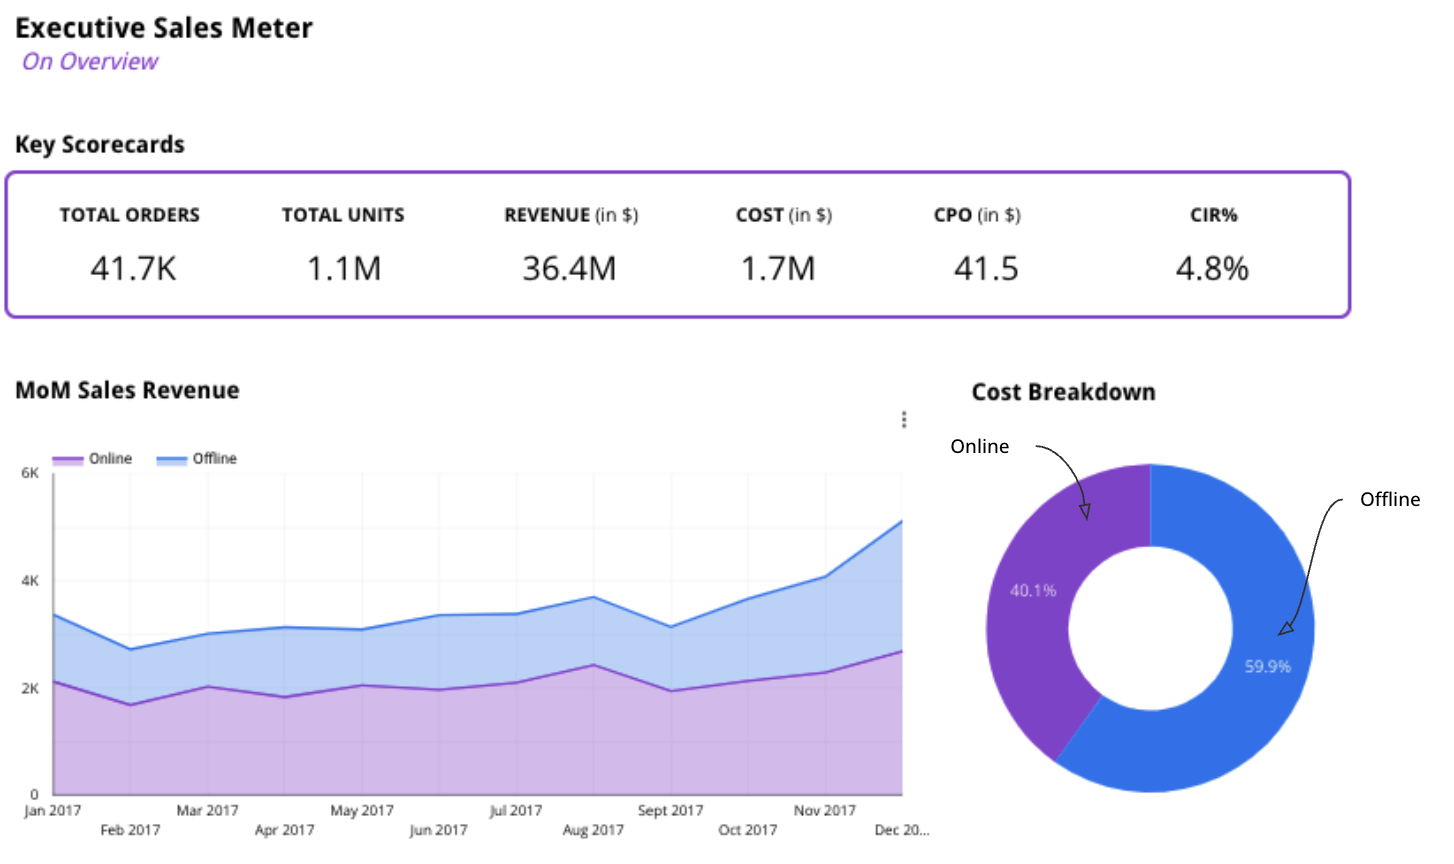

**Phase 4 - Insights**

**Channel Sales Contribution**
- Online accounts for 60% of total sales volume, highlighting a strong digital footprint
- However, the average basket size in-store is 5x larger than online, indicating richer, more committed purchases in physical locations

**Average Basket Value (ABV)**
- In-store ABV is around USD 61, while online ABV is only at USD 25. This suggests different buyer intent or pricing strategies — or possibly friction in the online buying experience for high-value items

**Pricing Inconsistency**
- Same SKUs show inconsistent pricing across online and offline
- Potential pricing errors, outdated listings, or intentional price steering need to be investigated